# Example script: Generate calibration curves and refit

This code example will show how to create the calibration plot and how we can refit is with a more robust performance

In [1]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

# Global libraries
import os
import torch
from torch.utils.data import DataLoader
from collections import defaultdict
from torchviz import make_dot 
from PIL import ImageFont
from torchinfo import summary

# Local libraries enivironment loading
import sys
from pathlib import Path
path_Project = Path(os.getcwd()).parent.parent
path_Git = path_Project.parent

def IncludeDirectory(path, index = 0, indexStop = -1):
    if(os.path.exists(path) and (index <= indexStop or indexStop == -1)):
        print(path)
        sys.path.append(path)
        children = os.listdir(path)
        for i in range(len(children)):
            pathChild = os.path.join(path,children[i])
            if(os.path.isdir(pathChild)):
                IncludeDirectory(pathChild, index + 1, indexStop)

# Activate the function
IncludeDirectory(path_Git,0,1)


c:\Users\r.van.der.wal\Documents\GitHub
c:\Users\r.van.der.wal\Documents\GitHub\pred_RT


In [2]:
import os
import pandas as pd
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt
import torch

#Local libraries
from src.config_presets.tools.get_config import get_config
from src.dataset.load_dataset import load_dataset, load_dataset_total
from src.models.tools.save_model import save_model
from src.training.train_multi import train
from src.utils.logging.logging import setup_logging
from src.utils.parse_args import parse_args
from src.utils.set_random_seed import set_random_seed
from src.hyper_opt.hyperHandler import HyperTuning_Handler
from src.utils.fileHandler import create_file, create_textfile
from src.dataset.ToxDataset import *
from src.evaluation.get_total_evaluation import get_total_evaluation
import src.visualization.calibration.temperature_scaling

import src.visualization.calibration.temperature_scaling as ts
from src.visualization.calibration.calibration_plots import adaptive_make_calibration_plots

c:\Users\r.van.der.wal\.conda\envs\test-env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# Import local libraries
from src.constants import DEVICE
from src.models.tools.get_multi_model import get_classification_model
from src.config_presets.tools.get_config import get_config
from src.config_presets.tools.load_config import load_config
from src.dataset.load_dataset import load_dataset, load_dataset_total, load_dataset_single, Complete_SanityCheck
from src.training.train_multi import get_output_results, validate
from src.evaluation.get_total_evaluation import get_total_evaluation

In [28]:
def get_and_filter_preds(preds, labels):
    mask = labels.isin([0, 1])

    preds = preds[mask]
    labels = labels[mask]

    preds = torch.tensor(preds.values)
    labels = torch.tensor(labels.values)

    preds_logits = torch.log(preds / (1 - preds))

    return preds_logits, preds, labels

### Load config file for project

In [5]:
# Path given
pathResultsChecked = r"C:\Users\r.van.der.wal\Documents\Detox_lung\Validate_Models\Trial_18_Check\Trial_18\Kfold1"

# Load config
config = load_config(os.path.join(pathResultsChecked,"DlModel_Config.yaml")) #get_config('DETOXLung_config')
config['paths']['csv'] = r"C:/Users/r.van.der.wal/Documents/Data/2024_09_04/ClinicalData/2024_11_01/"
config['paths']['images'] = r"C:/Users/r.van.der.wal/Documents/Data/2024_09_04/ImageData/"
config['training']['batch_size'] = 1

C:\Users\r.van.der.wal\Documents\Detox_lung\Validate_Models\Trial_18_Check\Trial_18\Kfold1\DlModel_Config.yaml


## One Model

In [90]:

# The load directory contains subdirectories of the folds with the given: model weights, patient cohort, etc.
load_directory = r"C:\Users\r.van.der.wal\Documents\Detox_lung\Validate_Models\Trial_18_Check\Trial_18"
result_directory = r"C:\Users\r.van.der.wal\Documents\Detox_lung\Validate_Models\Trial_18_Check\CalibrationCurve"

nameModel = "ResNet10"
model_weights = "DlModel_Weights.pth"
#exp_dir = os.path.join("final_models_2", exp_name) # "experiments/TransRP_ResNet18_m2 FIX"
#model_name = "TransRP_DenseNet121_m2"

# exp_name = "Best MedViT"
# exp_dir = os.path.join("final_models_2", exp_name) # "experiments/TransRP_ResNet18_m2 FIX"
# model_name = "MedViT_base"

prediction_scaling_methods = {
    "temperature scaling" : ts.TemperatureScaler() , 
    "platt scaling" : ts.PlattScaler(), 
    "isotonic regression": ts.IsotonicRegressionScaler(), 
    "beta calibration": ts.BetaCalibration()
    }

original_results = {}
method_results = {}

# Folds is dependent on amount of directories
folders = os.listdir(load_directory)
foldAmount = len(folders)

# Load model paths
path_csv = r"C:/Users/r.van.der.wal/Documents/Data/2024_09_04/ClinicalData/2024_11_01/"
path_images = r"C:/Users/r.van.der.wal/Documents/Data/2024_09_04/ImageData/"

for scaling_method, posthoc_model in prediction_scaling_methods.items():

    endpointArray = config['columns']['label']
    ens_preds_dict = {endpoint: None for endpoint in endpointArray}
    scaled_ens_preds_dict = {endpoint: None for endpoint in endpointArray}
    true_labels_dict = {endpoint: None for endpoint in endpointArray}

    for folder in folders:     # one folder per cross-validation fold
        fold_result_dir = os.path.join(result_directory ,folder)
        if(os.path.exists(fold_result_dir) == False):
            fold_proc_dir = os.path.join(load_directory, folder)
            get_total_evaluation(fold_proc_dir, fold_result_dir, path_csv, path_images, True, 1, single = True)
            get_total_evaluation(fold_proc_dir, fold_result_dir, path_csv, path_images, True, 2, single = True)
        
        # Load the validation and test set predictions
        df_val_preds = pd.read_csv(os.path.join(fold_result_dir,'val_pred.csv'), delimiter=',')
        df_val_label = pd.read_csv(os.path.join(fold_result_dir,'val_labels.csv'), delimiter=',')
        df_test_preds = pd.read_csv(os.path.join(fold_result_dir,'test_pred.csv'), delimiter=',')
        df_test_label = pd.read_csv(os.path.join(fold_result_dir,'test_labels.csv'), delimiter=',')

        #for endpoint in config.endpoint_list:
        # first find the scaling by using the validation set (train the posthoc model)
        endpoint = config['columns']['label'][0]
        val_logits, val_preds, val_labels = get_and_filter_preds((df_val_preds[endpoint]), (df_val_label[endpoint]))
        posthoc_model.fit(val_logits, val_labels)

        # use the posthoc model to scale the test set predictions
        test_logits, test_preds, test_labels = get_and_filter_preds((df_test_preds[endpoint]), (df_test_label[endpoint]))
        test_logreg_preds = posthoc_model.predict_proba(test_logits)
        test_logreg_preds = test_logreg_preds

        # save the (ensemble) predictions
        if ens_preds_dict[endpoint] is None:
            ens_preds_dict[endpoint] = test_preds/foldAmount
            scaled_ens_preds_dict[endpoint] = test_logreg_preds/foldAmount
            true_labels_dict[endpoint] = test_labels
        else:
            ens_preds_dict[endpoint] += test_preds/foldAmount
            scaled_ens_preds_dict[endpoint] += test_logreg_preds/foldAmount
   
    method_results[scaling_method] = scaled_ens_preds_dict


method_results["original"] = ens_preds_dict

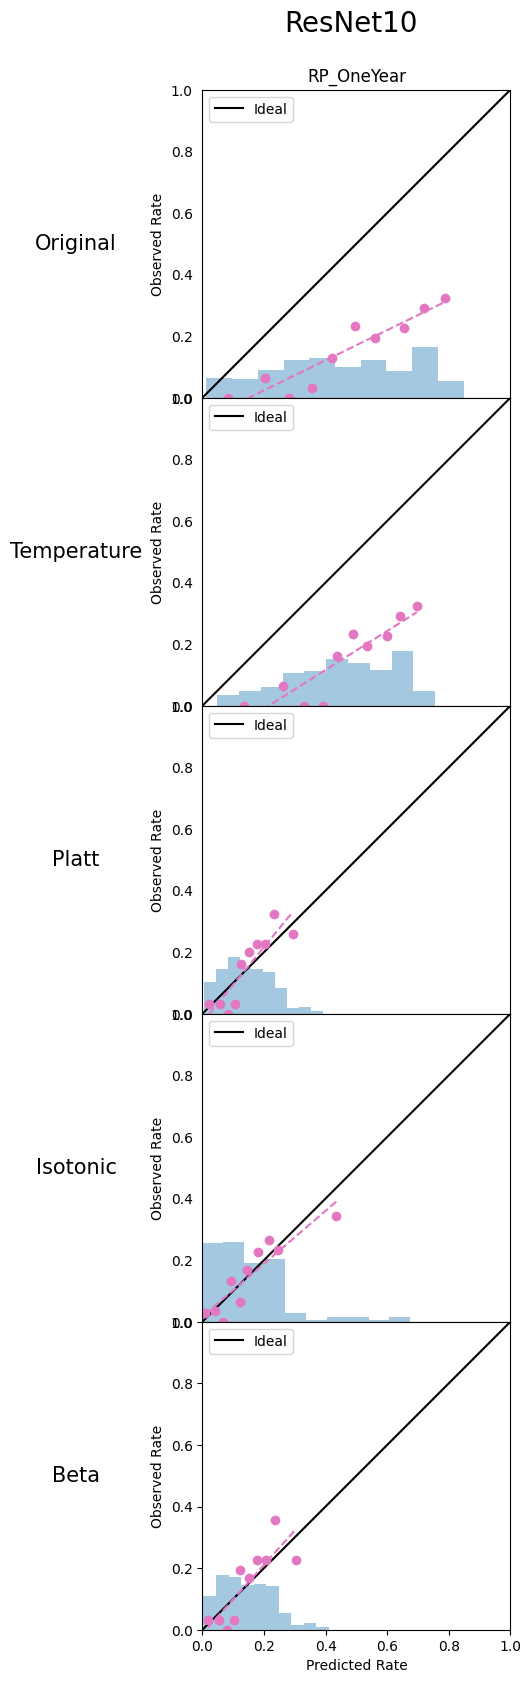

In [91]:
nameModel = "ResNet10"
resultDir_Plots = r"C:\Users\r.van.der.wal\Documents\Detox_lung\Validate_Models\Trial_18_Check\CalibrationCurveResults"

big_results_dict = [
    {
        "name": "Original",
        "preds": method_results["original"], 
        "labels": true_labels_dict
    }, {
        "name": "Temperature", 
        "preds": method_results["temperature scaling"], 
        "labels": true_labels_dict
    }, 
    {
        "name": "Platt", 
        "preds": method_results["platt scaling"], 
        "labels": true_labels_dict
    },
    {"name": "Isotonic", "preds": method_results["isotonic regression"], "labels": true_labels_dict},
    {"name": "Beta", "preds": method_results["beta calibration"], "labels": true_labels_dict}
]

rel_plot_export_dir = os.path.join(resultDir_Plots,"Temperature Scaling", f"{nameModel}_reliability.png")
cal_plot_export_dir = os.path.join(resultDir_Plots,"Temperature Scaling", f"{nameModel}_calibration.png")

%matplotlib inline
endpointArray = config['columns']['label']
#fig = adaptive_make_calibration_plots(config, row_dicts=big_results_dict, column_names=endpointArray, title=nameModel, 
#                                      mode='reliability', filedir=rel_plot_export_dir, return_fig=True)
#plt.show()
#plt.close()
fig = adaptive_make_calibration_plots(config, row_dicts=big_results_dict, column_names=endpointArray, title=nameModel, 
                                      mode='calibration', filedir=cal_plot_export_dir, return_fig=True)
plt.show()
plt.close()

In [92]:
#from src.utils.metrics import compute_AUCs_for_multiple_endpoints
from sklearn.metrics import roc_auc_score

#compute_AUCs_for_multiple_endpoints(config, method_results["original"], true_labels_dict)
endpointArray = config['columns']['label']
for endpoint in endpointArray :
    print(endpoint)
    for key in method_results.keys():
        
        auc_value = roc_auc_score(true_labels_dict[endpoint].clone().detach().cpu().numpy(), method_results[key][endpoint].clone().detach().cpu().numpy())
        #auc_value_new = roc_auc_score(true_labels_dict[endpoint].clone().detach().cpu().numpy(), method_results["temperature scaling"][endpoint].clone().detach().cpu().numpy())
        print(f"  {auc_value:.4f}",  key )

RP_OneYear
  0.7454 temperature scaling
  0.7371 platt scaling
  0.7340 isotonic regression
  0.7346 beta calibration
  0.7458 original
